<a href="https://colab.research.google.com/github/Ceilemarie/DrafonfruitClassification_EfficientNetB-0-MobileNetV2/blob/main/DragonFruit_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [1]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image # Added import for 'image'
from google.colab import files
import tensorflow as tf
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Added pandas import

In [2]:
train_path = '/content/drive/MyDrive/DragonFruit_Datasets/Final_Training_Dataset'

#Preview of Datasets

In [3]:
preview_datagen = ImageDataGenerator(rescale=1./255)

preview_gen = preview_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 3337 images belonging to 2 classes.


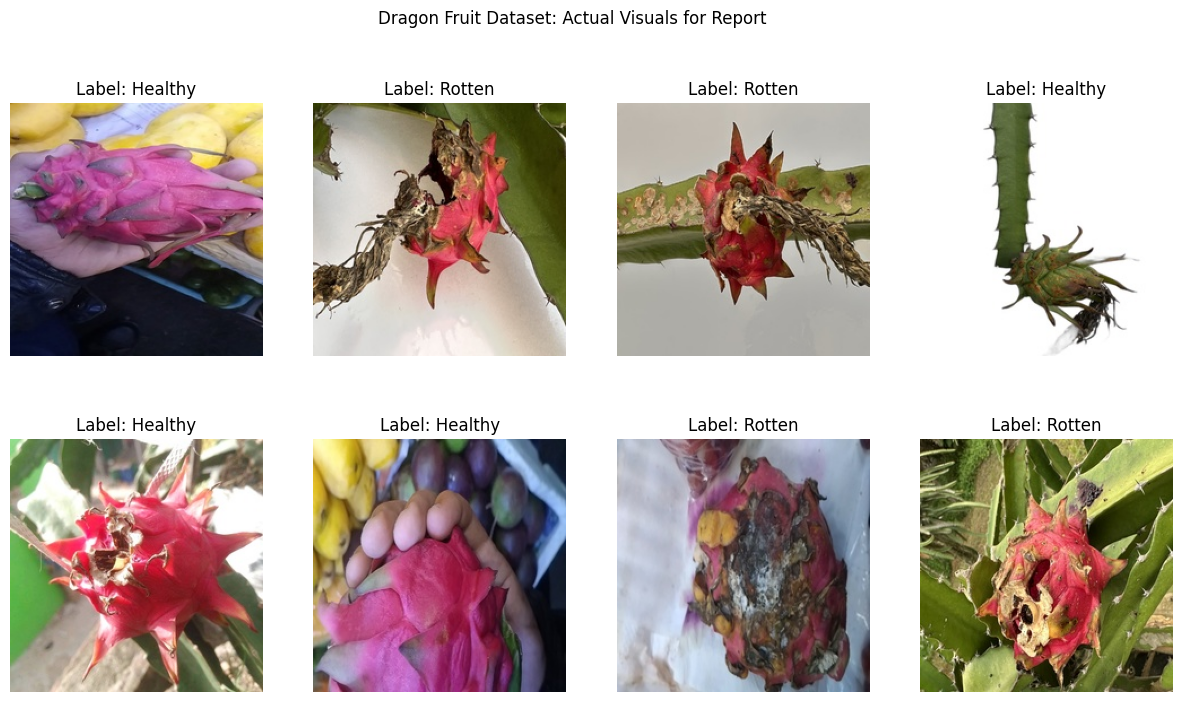

In [4]:
def show_clean_preview(generator):
    classes = list(generator.class_indices.keys())
    images, labels = next(generator)

    plt.figure(figsize=(15, 8))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        # Dahil rescale=1./255 lang, lilitaw na ang tamang kulay
        plt.imshow(images[i])
        label_text = "Healthy" if labels[i] == 0 else "Rotten"
        plt.title(f"Label: {label_text}")
        plt.axis('off')
    plt.suptitle("Dragon Fruit Dataset: Actual Visuals for Report")
    plt.show()

show_clean_preview(preview_gen)

#Adding weights

## TODO:

*   Total Count 1st cell should be a script that counts folder items






In [5]:
# Total counts base on  my datasets
healthy_count = 1739
rotten_count = 650
total = healthy_count + rotten_count

In [6]:
# Automatic calculation ng weights
# Formula: Total / (Classes * Count_per_Class)
weight_for_healthy = total / (2 * healthy_count)
weight_for_rotten = total / (2 * rotten_count)

In [7]:
print(f"Total images: {total}")
print(f"Weight for Healthy (Class 0): {weight_for_healthy:.2f}")
print(f"Weight for Rotten (Class 1): {weight_for_rotten:.2f}")

Total images: 2389
Weight for Healthy (Class 0): 0.69
Weight for Rotten (Class 1): 1.84


In [8]:
class_weight = {0: weight_for_healthy, 1: weight_for_rotten}
print("class_weight dictionary is:", class_weight)

class_weight dictionary is: {0: 0.6868890166762507, 1: 1.8376923076923077}


#Splitting

In [9]:
!pip install split-folders

In [10]:
import splitfolders

In [11]:
input_folder = '/content/drive/MyDrive/DragonFruit_Datasets/Final_Training_Dataset'
output_folder = '/content/drive/MyDrive/DragonFruit_Datasets/Dragonfruit_Final_Split'

# Split ratio: 70% Train, 15% Val, 15% Test
splitfolders.ratio(input_folder, output=output_folder, seed=1337, ratio=(.7, .15, .15), group_prefix=None)

print("Done!")

Copying files: 3337 files [12:34,  4.43 files/s]

Done!


#Setup Data Augmentation for Training

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalization
    rotation_range=30,       # Random rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Random flip
    fill_mode='nearest'
)

In [13]:
# Validation and Test only need Rescaling (No Augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [14]:
# Create the Generators
train_path = '/content/drive/MyDrive/DragonFruit_Datasets/Final_Training_Dataset'
val_path = '/content/drive/MyDrive/DragonFruit_Datasets/Dragonfruit_Final_Split/val'
test_path = '/content/drive/MyDrive/DragonFruit_Datasets/Dragonfruit_Final_Split/test'

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=(224, 224), batch_size=32, class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_path, target_size=(224, 224), batch_size=32, class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

Found 3337 images belonging to 2 classes.
Found 684 images belonging to 2 classes.
Found 687 images belonging to 2 classes.


#Load Model - EfficientNetB0

In [15]:
# Load EfficientNet-B0 without the top layer
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = False # Freeze the base model first

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# Build the final layers
model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3), # Improvement: Regularization to prevent overfitting
    layers.Dense(1, activation='sigmoid') # Binary classification (Healthy vs Rotten)
])

model_eff.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Training

In [17]:
my_weights = {0: weight_for_healthy, 1: weight_for_rotten}

In [18]:
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <--- Importante ito para sa EfficientNet
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [19]:
val_test_datagen_eff = ImageDataGenerator(preprocessing_function=preprocess_input)

In [20]:
train_gen_eff = train_datagen_eff.flow_from_directory(train_path, target_size=(224, 224), batch_size=32, class_mode='binary')
val_gen_eff = val_test_datagen_eff.flow_from_directory(val_path, target_size=(224, 224), batch_size=32, class_mode='binary')

Found 3337 images belonging to 2 classes.
Found 684 images belonging to 2 classes.


In [21]:
print('Converting generators to tf.data.Dataset objects...')
# Convert ImageDataGenerators to tf.data.Dataset
train_ds_eff = tf.data.Dataset.from_generator(
    lambda: train_gen_eff,
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, 224, 224, 3], [None, 1])
).prefetch(tf.data.AUTOTUNE)

Converting generators to tf.data.Dataset objects...


In [22]:
val_ds_eff = tf.data.Dataset.from_generator(
    lambda: val_gen_eff,
    output_types=(tf.float32, tf.float32),
    output_shapes=([None, 224, 224, 3], [None, 1])
).prefetch(tf.data.AUTOTUNE)
print('Conversion complete.')

Conversion complete.


In [23]:
# Re-build Model with GlobalMaxPooling for better detail detection
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = True # Gawin nating trainable pero lower learning rate

In [24]:
model_eff = models.Sequential([
    base_model_eff,
    layers.GlobalMaxPooling2D(), # Pinalitan ang Average ng Max para sa "Rot" spots
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

In [25]:
model_eff.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [27]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_model_eff.keras', monitor='val_loss', save_best_only=True)

In [ ]:
print("Re-training with Early Stopping and Checkpoints...")
history_eff = model_eff.fit(
    train_gen_eff, # Changed from train_generator to train_gen_eff
    validation_data=val_gen_eff, # Changed from val_generator to val_gen_eff
    epochs=15, # Kahit naka-15 tayo, titigil yan kusa pag pumangit na ang result
    class_weight=class_weight,
    callbacks=[early_stop, checkpoint]
)

Re-training with Early Stopping and Checkpoints...
Epoch 1/15
 13/105 ━━━━━━━━━━━━━━━━━━━━ 17:13 11s/step - accuracy: 0.5098 - loss: 1.2843

#Training & Validation

In [ ]:
# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_eff.history['accuracy'], label='Training Accuracy', color='blue', lw=2)
plt.plot(history_eff.history['val_accuracy'], label='Validation Accuracy', color='orange', lw=2)
plt.title('EfficientNet-B0: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

In [ ]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_eff.history['loss'], label='Training Loss', color='blue', lw=2)
plt.plot(history_eff.history['val_loss'], label='Validation Loss', color='orange', lw=2)
plt.title('EfficientNet-B0: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#Confusion Matrices

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
# Kunin ang predictions mula sa Test Set
test_gen_eff = val_test_datagen_eff.flow_from_directory(test_path, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False)
test_gen_eff.reset()
y_pred_prob = model_eff.predict(test_gen_eff)
y_pred = (y_pred_prob > 0.5).astype("int32")
y_true = test_gen_eff.classes

In [ ]:
# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Rotten'],
            yticklabels=['Healthy', 'Rotten'])
plt.title('Final Confusion Matrix (Task 5)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#Classification Report (Precision, Recall, F1-Score)

In [ ]:
print("\n" + "="*30)
print("CLASSIFICATION REPORT")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Rotten']))

#Training - MobileNetV2

In [ ]:
# 1. Setup MobileNetV2
base_model_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_mobile.trainable = True # Fine-tuning mode

In [ ]:
model_mobile = models.Sequential([
    base_model_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model_mobile.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

In [ ]:
# 2. Training
print("Training MobileNetV2")
history_mobile = model_mobile.fit(
    train_gen_eff, # Pwedeng gamitin ang same generator
    validation_data=val_gen_eff,
    epochs=15,
    class_weight=class_weight,
    callbacks=[early_stop, checkpoint]
)

In [ ]:
# Predict using MobileNetV2
y_pred_prob_mobile = model_mobile.predict(val_gen_eff) # MobileNet can use the same generator
y_pred_mobile = (y_pred_prob_mobile > 0.5).astype("int32")
y_true_mobile = val_gen_eff.classes

In [ ]:
# Plot for MobileNetV2
plt.figure(figsize=(12, 5))

In [ ]:
# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history_mobile.history['accuracy'], label='Train Accuracy', color='#2ca02c', lw=2)
plt.plot(history_mobile.history['val_accuracy'], label='Val Accuracy', color='#d62728', lw=2)
plt.title('MobileNetV2: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

In [ ]:
# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history_mobile.history['loss'], label='Train Loss', color='#2ca02c', lw=2)
plt.plot(history_mobile.history['val_loss'], label='Val Loss', color='#d62728', lw=2)
plt.title('MobileNetV2: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_true, y_pred_mobile), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Healthy', 'Rotten'], yticklabels=['Healthy', 'Rotten'])
plt.title('Confusion Matrix: MobileNetV2')
plt.show()

#Classification Report - MobileNetV2

In [ ]:
print("--- MOBILENETV2 CLASSIFICATION REPORT ---")
val_gen_eff.reset()
y_pred_mobile = (model_mobile.predict(val_gen_eff) > 0.5).astype("int32")
y_true = val_gen_eff.classes
print(classification_report(y_true, y_pred_mobile, target_names=['Healthy', 'Rotten']))

#Model Comparison & Conclusion

In [ ]:
# Comparison Graphs
plt.figure(figsize=(14, 5))

In [ ]:
# Accuracy Comparison
plt.subplot(1, 2, 1)
plt.plot(history_eff.history['val_accuracy'], label='EfficientNet-B0', marker='o')
plt.plot(history_mobile.history['val_accuracy'], label='MobileNetV2', marker='x')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

In [ ]:
# Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history_eff.history['val_loss'], label='EfficientNet-B0', marker='o')
plt.plot(history_mobile.history['val_loss'], label='MobileNetV2', marker='x')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

#test

In [ ]:
model_eff.load_weights('best_model_eff.keras', skip_mismatch=True)

print("Saved old training for now")

In [ ]:
base_model_eff.trainable = False

#Preview of UI

In [ ]:
uploaded = files.upload()

In [ ]:
for fn in uploaded.keys():
    path = fn
    img = image.load_img(path, target_size=(224, 224))

    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    classes = model_eff.predict(x)

    # 5. I-display ang resulta
    plt.imshow(img)
    plt.axis('off')

    # Sigmoid logic: > 0.5 is Rotten (1), <= 0.5 is Healthy (0)
    if classes[0] > 0.5:
        result = "ROTTEN"
        confidence = classes[0][0] * 100
    else:
        result = "HEALTHY"
        confidence = (1 - classes[0][0]) * 100

    plt.title(f"Prediction: {result} ({confidence:.2f}%)")
    plt.show()